In [ ]:
# ==========================================
# 1. 라이브러리 임포트 및 기본 설정
# ==========================================
import os             # 파일 및 폴더 경로를 다루기 위한 기본 라이브러리
import json           # 정답 라벨 데이터(.json)를 읽기 위한 라이브러리
import random         # 오디오를 무작위로 자르기(Random Crop) 위한 라이브러리
import librosa        # 오디오 파동을 주파수 이미지(Mel-Spectrogram)로 변환하는 핵심 라이브러리
import numpy as np    # 숫자 배열 계산을 위한 라이브러리
import torch          # 파이토치(딥러닝 프레임워크) 
import torch.nn as nn # 딥러닝 모델의 뼈대(신경망)를 구성하는 모듈
from torch.utils.data import Dataset, DataLoader # 데이터를 모델에 차례대로 먹여주기 위한 도구들
from torchvision import models # 이미 검증된 유명한 모델(ResNet50 등)을 불러오기 위한 라이브러리
from tqdm.auto import tqdm # 훈련 진행 상황을 진행바(Progress Bar)로 보여주는 예쁜 라이브러리
import matplotlib.pyplot as plt # 소리 이미지를 눈으로 확인하기 위해 그리는 라이브러리

# AI가 훈련을 할 때 그래픽카드(GPU)를 쓸지 중앙처리장치(CPU)를 쓸지 결정합니다.
# cuda가 뜨면 GPU를 사용하여 엄청나게 빠르게 훈련합니다.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'현재 사용 중인 디바이스: {device}')


In [ ]:
# ==========================================
# 2. 오디오 데이터셋 준비 (Dataset 클래스)
# - 수천 개의 오디오 파일을 어떻게 AI에게 넘겨줄지 정의함
# ==========================================
class SpeakerDataset(Dataset):
    def __init__(self, label_dir, audio_dir, max_time_steps=256, is_train=True):
        self.audio_dir = audio_dir
        self.max_time_steps = max_time_steps # AI에게 보여줄 이미지의 가로 길이 (3초 분량)
        self.is_train = is_train
        self.samples = [] # 훈련에 쓸 정답지 목록을 담을 바구니
        
        # 1. 라벨(JSON) 폴더를 뒤지면서 파일 하나하나 열어보기
        for json_name in os.listdir(label_dir):
            if not json_name.endswith('.json'): continue
            
            json_path = os.path.join(label_dir, json_name)
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            # 2. JSON 파일 이름(예: 001.json)을 바탕으로 짝꿍 오디오 파일(001.wav) 찾기
            wav_name = json_name.replace('.json', '.wav')
            wav_path = os.path.join(audio_dir, wav_name)
            if not os.path.exists(wav_path): continue
                
            # 3. JSON 안에 적힌 "누가(speaker), 언제부터(startAt), 언제까지(endAt) 말했는지" 정보 수집
            for utt in data.get('utterances', []):
                self.samples.append({
                    'wav_path': wav_path,
                    'start_ms': utt['startAt'],   # 발화 시작 시간
                    'end_ms': utt['endAt'],       # 발화 종료 시간
                    'label': utt['speaker']       # 1: 신고자(Caller), 0: 대원(Agent)
                })
                
    def __len__(self):
        # 문제 갯수 반환
        return len(self.samples)
    
    def __getitem__(self, idx):
        # idx번째 문제 반환
        sample = self.samples[idx]
        sr = 16000 # 음질 설정 (1초에 16000개의 소리 조각)
        
        # 4. 오디오 파일을 통째로 불러온 뒤, 해당 사람이 말한 구간만 가위로 싹둑 자르기
        y, _ = librosa.load(sample['wav_path'], sr=sr)
        start_sample = int((sample['start_ms'] / 1000.0) * sr)
        end_sample = int((sample['end_ms'] / 1000.0) * sr)
        cut_audio = y[start_sample:end_sample]
        
        # 5. 소리 파동을 Mel-Spectrogram로 변환
        mel_spec = librosa.feature.melspectrogram(y=cut_audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # 6. 이미지 가로 길이(시간) 통일하기 (항상 3초(256) 길이로 맞추기)
        current_length = mel_spec_db.shape[1]
        if current_length < self.max_time_steps:
            # 소리가 3초보다 짧으면? -> 남는 빈 공간을 색칠해서 채움(Padding)
            pad_width = self.max_time_steps - current_length
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        elif current_length > self.max_time_steps:
            # 소리가 3초보다 길면? -> 넘치는 부분을 가위로 잘라냄 (Crop)
            if self.is_train:
                # 훈련 중일 때는 '아무 곳이나 랜덤으로 3초' 자르기 (다양한 경험을 위해)
                start_idx = random.randint(0, current_length - self.max_time_steps)
            else:
                # 시험 볼 때는 항상 가장 공평하게 '정중앙 3초' 자르기
                start_idx = (current_length - self.max_time_steps) // 2
            mel_spec_db = mel_spec_db[:, start_idx : start_idx + self.max_time_steps]
            
        # 7. AI가 먹을 수 있는 형태(Tensor)로 포장해서 정답지와 함께 반환!
        mel_tensor = torch.tensor(mel_spec_db, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(sample['label'], dtype=torch.float32)
        
        return mel_tensor, label_tensor


사용 중인 디바이스: cuda


In [ ]:
# ==========================================
# 3. 인공지능 뇌 구조 설계 (ResNet50 모델)
# - 컬러 사진을 구별하는 똑똑한 뇌(ResNet50)를 가져와서, 흑백 소리 이미지를 보게끔 개조합니다.
# ==========================================
class AudioResNet(nn.Module):
    def __init__(self):
        super(AudioResNet, self).__init__()
        # 이미 훈련이 되어있는 강력한 뇌(pretrained=True)를 다운받습니다.
        self.model = models.resnet50(pretrained=True)
        
        # 원본 ResNet은 눈이 3개(RGB 3채널)인데, 우리의 소리 이미지는 흑백(1채널)입니다.
        # 따라서 눈을 1개짜리로 개조해 줍니다.
        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        
        # 모델의 최종 입(출력층) 개조하기
        # 원래 1000개의 정답을 말하던 입을 다물게 하고, 1개(0인지 1인지)만 대답하도록 바꿉니다.
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 1)
        
    def forward(self, x):
        # 사진(x)을 보여주면, 뇌(self.model)를 거쳐서 정답을 뱉어냅니다.
        return self.model(x)


In [8]:
# ==========================================
# 4. 데이터 세팅 및 시각화 도구 준비
# ==========================================
BATCH_SIZE = 32 # 한 번에 AI에게 보여줄 문제의 개수 (모의고사 1세트 = 32문제)

# 훈련용 교재(train)와 모의고사 교재(val)를 만듭니다.
train_dataset = SpeakerDataset(label_dir='../data/train/label', audio_dir='../data/train/audio', is_train=True)
val_dataset = SpeakerDataset(label_dir='../data/val/label', audio_dir='../data/val/audio', is_train=False)

# 교재에서 문제를 32개씩 차례대로 뽑아주는 기계를 만듭니다.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 시각화(테스트)를 위해 모의고사 문제 딱 4개만 미리 빼둡니다.
test_batch_x, test_batch_y = next(iter(val_loader))
test_batch_x = test_batch_x[:4].to(device)  
test_batch_y = test_batch_y[:4].to(device)

model = AudioResNet().to(device)

def show_predictions(model, batch_x, batch_y, title_prefix=""):
    """
    AI가 문제를 풀고, 그 결과를 색칠해서 화면에 그려주는 친절한 함수입니다.
    정답을 맞히면 파란색, 틀리면 빨간색으로 표시됩니다.
    """
    model.eval() # AI에게 "지금은 훈련(공부)이 아니라 시험 보는 중이야!" 라고 알려줍니다.
    with torch.no_grad():
        outputs = model(batch_x)
        # 0.5점 이상이면 1(신고자), 미만이면 0(대원)으로 찍습니다.
        preds = torch.round(torch.sigmoid(outputs)).squeeze(-1)
    
    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        img = batch_x[i].cpu().squeeze(0).numpy()
        actual = int(batch_y[i].item())
        predicted = int(preds[i].item())
        
        plt.imshow(img, cmap='viridis', origin='lower', aspect='auto')
        
        # 정답 여부에 따라 색상 결정
        color = 'blue' if actual == predicted else 'red'
        
        title = f"[Actual] {'Caller' if actual==1 else 'Agent'}\n[{title_prefix}] {'Caller' if predicted==1 else 'Agent'}"
        plt.title(title, color=color, fontweight='bold')
        plt.xlabel('Time Steps')
        plt.ylabel('Mel Frequency')
    plt.tight_layout()
    plt.show()


c:\Users\user\Desktop\DCC\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.5MB/s]


## 🧪 1. [학습 전] 백지상태의 AI에게 문제 풀려보기

아직 가중치(Weight)가 업데이트되지 않은 바보 상태의 AI입니다. 눈감고 찍는 수준(찍기 확률 50%)이므로 정답(Actual)과 예측(Predicted)이 틀릴 확률이 높습니다. (틀린 예측은 <span style="color:red">빨간색 글씨</span>로 나타납니다)

========== [학습 전] 모델의 찍기 결과 ==========


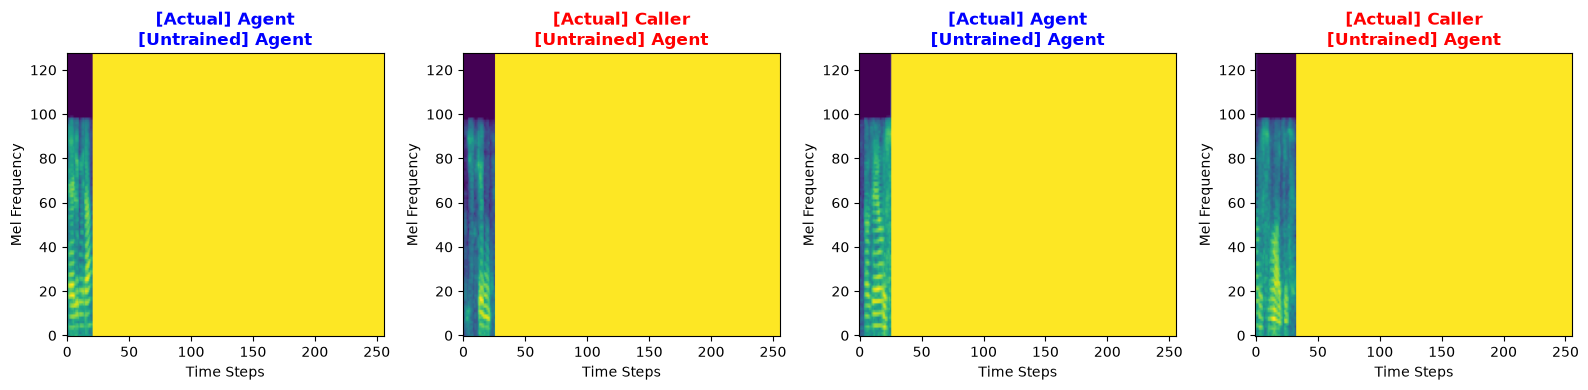

In [9]:
print("========== [학습 전] 모델의 찍기 결과 ==========")
show_predictions(model, test_batch_x, test_batch_y, title_prefix="Untrained")

## 🚀 2. 지도학습(Supervised Learning) 훈련시키기

AI에게 수만 장의 데이터를 보여주고, 정답과 틀렸을 때 가중치를 수정(Backpropagation)시킵니다.

In [10]:
EPOCHS = 3 # 빨리 확인하기 위해 3번만 반복
LEARNING_RATE = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batch_x, batch_y in progress_bar:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()      # 여기서 가중치를 어느 방향으로 바꿀지 계산
        optimizer.step()     # 여기서 실제로 가중치(뇌세포)를 업데이트하여 더 똑똑해짐
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'Loss': loss.item()})

print("🎉 학습 완료!")

Epoch 1/3:   0%|          | 0/27286 [00:00<?, ?it/s]

c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1888
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1760
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1920
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2032
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1280
  warnings.warn(
c:\Users\u

Epoch 2/3:   0%|          | 0/27286 [00:00<?, ?it/s]

Epoch 3/3:   0%|          | 0/27286 [00:00<?, ?it/s]

🎉 학습 완료!


## ✨ 3. [학습 후] 똑똑해진 AI에게 똑같은 문제 다시 풀려보기

이제 훈련을 마친 AI에게 **아까 틀렸던 그 4문제**를 똑같이 다시 주어봅니다.
스펙트로그램 이미지의 특징(삐 소리, 잡음 등)을 완벽히 이해했다면 모두 <span style="color:blue">파란색 글씨(정답)</span>로 맞춰낼 것입니다!

========== [학습 후] 모델의 정답 예측 결과 ==========


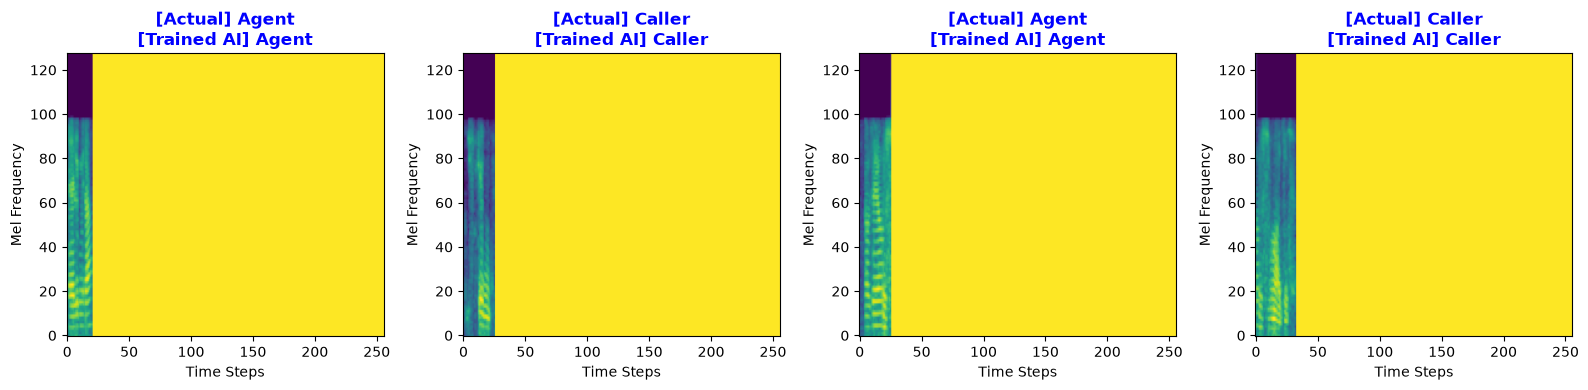

In [11]:
print("========== [학습 후] 모델의 정답 예측 결과 ==========")
show_predictions(model, test_batch_x, test_batch_y, title_prefix="Trained AI")

In [12]:
# 4단계: 훈련된 최고의 뇌 상태(가중치)를 파일로 저장하기
import os
import torch
save_path = 'best_model.pt'
torch.save(model.state_dict(), save_path)
print(f"성공적으로 모델 가중치가 {save_path}에 저장되었습니다! 이제 inference.py를 실행할 수 있습니다.")


성공적으로 모델 가중치가 best_model.pt에 저장되었습니다! 이제 inference.py를 실행할 수 있습니다.
